In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing as pps
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

In [2]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [3]:
data = pd.read_csv(r"../data/dataset.csv")

In [4]:
data_clean_2=pps.clean_data_2(data)
print(data.shape)
print(data_clean_2.shape)

(768, 9)
(708, 11)


In [5]:
data_clean_2.head()

,index_tab,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insuline_bool,SkinThickness_bool
0,0,6,148,72,35,0,33.6,0.627,50,0,1
1,1,1,85,66,29,0,26.6,0.351,31,0,1
2,2,8,183,64,0,0,23.3,0.672,32,0,0
3,3,1,89,66,23,94,28.1,0.167,21,1,1
5,5,5,116,74,0,0,25.6,0.201,30,0,0


In [6]:
colonnes_cluster=['Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']

Appliquer un scaler sur les données choisies

In [7]:
X=data_clean_2[colonnes_cluster]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

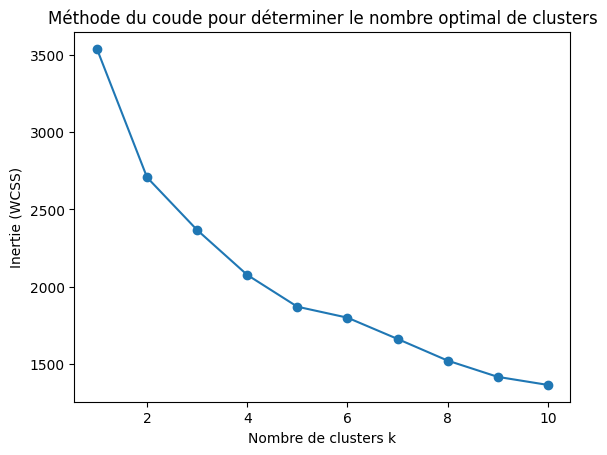

In [8]:

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Tracer la courbe du coude
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (WCSS)')
plt.title('Méthode du coude pour déterminer le nombre optimal de clusters')
plt.show()

Selon le graphique nous avons  clusters

Determination des clusters

In [9]:
data_clean_2= pps.make_cluster(data_clean_2,2,['Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age'],True)
data_clean_2.head()

,index_tab,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insuline_bool,SkinThickness_bool,cluster
0,0,6,148,72,35,0,33.6,0.627,50,0,1,0
1,1,1,85,66,29,0,26.6,0.351,31,0,1,1
2,2,8,183,64,0,0,23.3,0.672,32,0,0,0
3,3,1,89,66,23,94,28.1,0.167,21,1,1,1
5,5,5,116,74,0,0,25.6,0.201,30,0,0,1


PCA

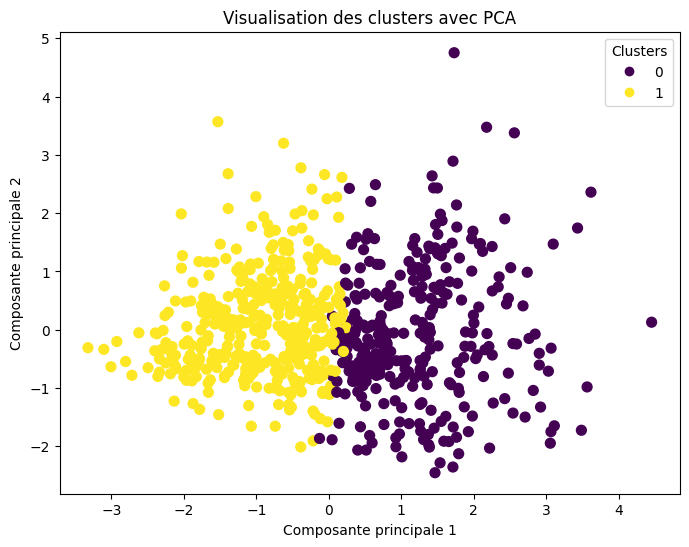

In [10]:
# Réduction à 2 dimensions avec PCA
labels=data_clean_2['cluster']
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tracé des points colorés par cluster
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)

# Ajout de la légende
legend = plt.legend(*scatter.legend_elements(), 
                    title="Clusters", 
                    loc="best")  # 'loc' peut être ajusté (ex: "upper right")

plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title('Visualisation des clusters avec PCA')
plt.show()


In [11]:
# Afficher la part de variance expliquée par PC1 et PC2
print("Variance expliquée par PC1 : {:.2%}".format(pca.explained_variance_ratio_[0]))
print("Variance expliquée par PC2 : {:.2%}".format(pca.explained_variance_ratio_[1]))
print("Variance expliquée cumulée : {:.2%}".format(sum(pca.explained_variance_ratio_)))

Variance expliquée par PC1 : 34.79%
Variance expliquée par PC2 : 20.74%
Variance expliquée cumulée : 55.53%


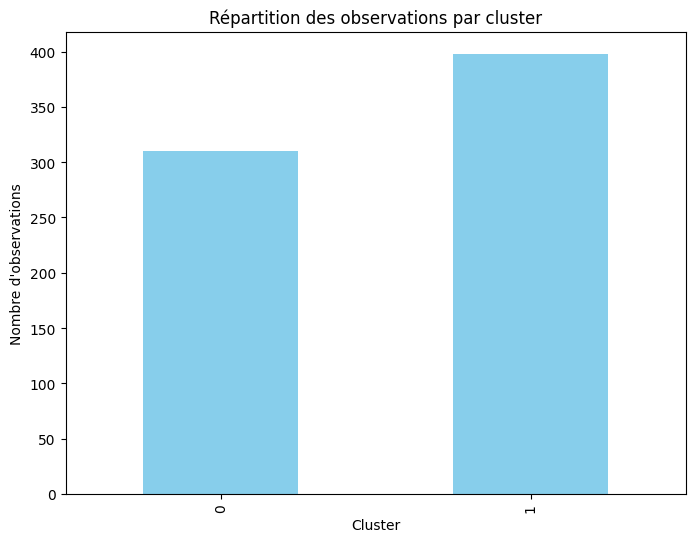

cluster
0    310
1    398
Name: count, dtype: int64


In [12]:
cluster_counts = data_clean_2['cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
cluster_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Cluster')
plt.ylabel("Nombre d'observations")
plt.title('Répartition des observations par cluster')
plt.show()
print(cluster_counts)

Calcul des moyennes pour chaque cluster

In [13]:
moyennes_par_cluster = data_clean_2.groupby('cluster').agg(
    Mean_Glucose=('Glucose', 'mean'),
    Mean_BloodPressure=('BloodPressure', 'mean'),
    Mean_BMI=('BMI', 'mean'),
    Mean_DPF=('DiabetesPedigreeFunction', 'mean'),
    Mean_Age=('Age', 'mean')
)
print(moyennes_par_cluster)

         Mean_Glucose  Mean_BloodPressure   Mean_BMI  Mean_DPF   Mean_Age
cluster                                                                  
0          141.858065           79.709677  35.264194  0.507774  41.261290
1          105.929648           66.804020  29.855779  0.431000  27.351759


Il semble que le cluster 0 est celui à risque de diabéte et le cluster 1 celui à faible risque